In [1]:
from os import listdir
from os.path import join
import imageio

def make_gif(base, path='screenshots', name='movie.gif'):
    print(base)
    files = sorted(listdir(join(base, path)))
    images = [imageio.imread(join(base, path, f)) for f in files]
    imageio.mimsave(join(base, name), images, fps=20)

In [2]:
import concurrent.futures as cc

In [3]:
sims = listdir('../output')
nsims = len(sims)

In [5]:
with cc.ThreadPoolExecutor() as executor: 
  for i in range(nsims):                                            
    base = f'../output/sim_{i:03}'                                       
    executor.submit(make_gif(base))

../output/sim_000
../output/sim_001
../output/sim_002
../output/sim_003
../output/sim_004
../output/sim_005
../output/sim_006
../output/sim_007
../output/sim_008
../output/sim_009
../output/sim_010
../output/sim_011
../output/sim_012
../output/sim_013
../output/sim_014
../output/sim_015
../output/sim_016
../output/sim_017
../output/sim_018
../output/sim_019
../output/sim_020
../output/sim_021
../output/sim_022
../output/sim_023
../output/sim_024
../output/sim_025
../output/sim_026
../output/sim_027
../output/sim_028
../output/sim_029
../output/sim_030
../output/sim_031
../output/sim_032
../output/sim_033
../output/sim_034
../output/sim_035
../output/sim_036
../output/sim_037
../output/sim_038
../output/sim_039
../output/sim_040
../output/sim_041
../output/sim_042
../output/sim_043
../output/sim_044
../output/sim_045
../output/sim_046
../output/sim_047
../output/sim_048
../output/sim_049
../output/sim_050
../output/sim_051
../output/sim_052
../output/sim_053
../output/sim_054
../output/

In [15]:
df.sort_values(by='beta', ascending=False)

,fitness,beta,q,ave,max,imp,grd
223,"[1.1257580193216512, 1.1504764955553777, 1.178...",9953.826940,False,1.191340,1.843909,49.680000,-0.000024
49,"[1.1356986715991255, 1.1567472245601378, 1.171...",9952.677023,False,1.115244,1.789046,50.360000,-0.000032
166,"[1.1168486156656012, 1.1341681574239715, 1.154...",9944.580199,False,1.183113,1.819349,50.446667,-0.000022
32,"[1.116063454259346, 1.1398980500040456, 1.1483...",9933.199794,False,1.082866,1.760901,50.306667,-0.000031
224,"[1.1099597006332758, 1.123757338551859, 1.1438...",9909.623524,False,1.131519,1.795892,49.760000,-0.000026
...,...,...,...,...,...,...,...
127,"[1.0971927635683094, 1.1223878211531546, 1.139...",-9559.201801,False,0.832547,12.802878,24.193333,-0.000073
118,"[1.115634292415295, 1.140562573146616, 1.17197...",-9562.240080,False,0.837765,10.865124,24.486667,-0.000074
4,"[1.1351080697655012, 1.1526717557251909, 1.168...",-9646.643157,False,0.826154,2.679219,23.960000,-0.000076
68,"[1.1303981816651234, 1.1597353118107079, 1.183...",-9679.875681,False,0.853075,2.681247,24.226667,-0.000075


In [4]:
import pandas as pd
import numpy as np
import json
import re

In [5]:
datas = {}
betas = {}
bad = []
for f in sims: 
    n = int(re.search(r'\d+', f)[0])
    base = f'../output/{f}/'
    try:
        datas[n] = [list(map(lambda x: x[1], json.load(open(base+'data.json', 'r')))), json.load(open(base+'genome.json', 'r'))['signaling']['halfexpress']]
    except Exception as e:
        print(n, e)
        bad.append(n)

264 [Errno 2] No such file or directory: '../output/sim_264/data.json'
263 [Errno 2] No such file or directory: '../output/sim_263/data.json'
252 [Errno 2] No such file or directory: '../output/sim_252/data.json'
262 [Errno 2] No such file or directory: '../output/sim_262/data.json'
265 [Errno 2] No such file or directory: '../output/sim_265/data.json'
260 [Errno 2] No such file or directory: '../output/sim_260/data.json'
258 [Errno 2] No such file or directory: '../output/sim_258/data.json'
267 [Errno 2] No such file or directory: '../output/sim_267/data.json'
269 [Errno 2] No such file or directory: '../output/sim_269/data.json'
268 [Errno 2] No such file or directory: '../output/sim_268/data.json'
257 [Errno 2] No such file or directory: '../output/sim_257/data.json'
259 [Errno 2] No such file or directory: '../output/sim_259/data.json'
266 [Errno 2] No such file or directory: '../output/sim_266/data.json'
261 [Errno 2] No such file or directory: '../output/sim_261/data.json'


In [6]:
df = pd.DataFrame.from_dict(datas, columns=['fitness', 'beta'], orient='index') 

In [8]:
df.loc[:, 'q'] = df.fitness.apply(lambda x: x[0] < x[-1])
df.loc[:, 'ave'] = df.fitness.apply(np.mean)
df.loc[:, 'max'] = df.fitness.apply(max)
df.loc[:, 'imp'] = df.fitness.apply(lambda x: (np.diff(x) > 0).sum()/len(x)*100)
df.loc[:, 'grd'] = df.fitness.apply(lambda x: np.diff(x).sum()/len(x))

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('axes', facecolor='#E6E6E6', edgecolor='none',
       axisbelow=True, grid=True)
plt.rc('grid', color='w', linestyle='solid')
plt.rc('xtick', top=False, bottom=False)
plt.rc('ytick', left=False, right=False)
#plt.rc('xtick.major', pad=0.5)
#plt.rc('ytick.major', pad=0.5)
plt.rc('patch', edgecolor='#E6E6E6')
plt.rc('lines', linewidth=2)
plt.rc('font', family='Helvetica Nueue')

In [124]:
def save(f, dpi=600):
    plt.savefig(f, dpi=dpi)

In [135]:
def plot(x=None, y=None, t=None):
    if x is not None:
        plt.xlabel(x)
    if y is not None:
        plt.ylabel(y)
    if t is not None:
        plt.title(t)

<Figure size 1152x648 with 0 Axes>

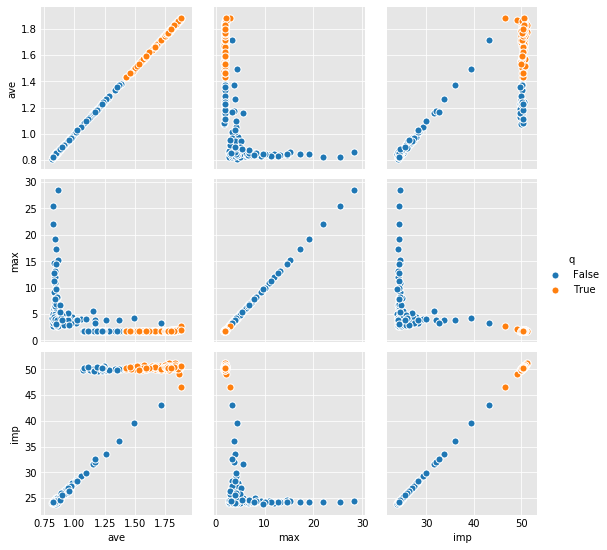

In [149]:
plt.figure(figsize=(16, 9))
g = sns.PairGrid(df[['ave', 'max', 'imp', 'q']], hue="q")
g.map(plt.scatter, s=50, edgecolor="white")
g.add_legend()
g.savefig('pairplot.png', dpi=600)

In [166]:
plot_df

,beta,q,ave,max,imp
178,-6911.103977,False,0.821515,4.246801,24.353333
147,2985.797679,True,1.781887,1.816129,50.933333
140,-3219.222975,False,1.000250,3.570342,27.973333
149,649.568314,True,1.818372,1.881865,50.653333
182,3763.254736,True,1.733598,1.781422,50.346667
...,...,...,...,...,...
161,3691.160041,True,1.770777,1.805383,50.180000
135,9527.769460,False,1.223595,1.825236,50.326667
132,-8885.118745,False,0.824961,21.948582,24.286667
104,-2641.973302,False,1.167604,3.329193,32.653333


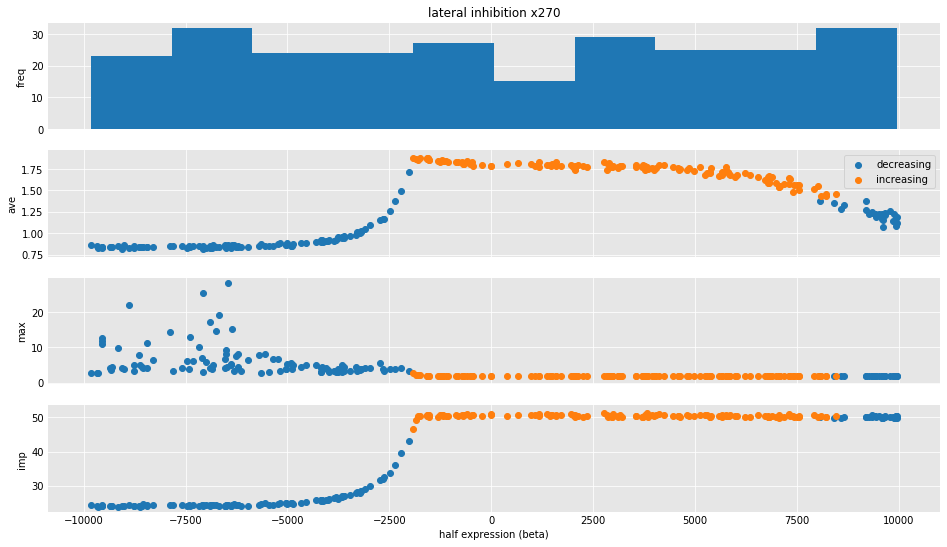

In [216]:
fig = plt.figure(figsize=(16, 9))
axs = fig.subplots(4, 1, sharex='all')
axs[0].hist(plot_df.beta)
axs[0].set_ylabel('freq')
i = 1
for f in plot_df.columns:
    if f != 'q' and f != 'beta':
        for v, chunk in plot_df.groupby('q'):
            if v:
                clr = 'C1'
                lab = 'increasing'
            else:
                clr = 'C0'
                lab = 'decreasing'
            axs[i].scatter(chunk.beta, chunk[f], c=clr, label=lab)
        axs[i].set_ylabel(f)
        i += 1
axs[1].legend()
plt.xlabel('half expression (beta)')
axs[0].set_title(f'lateral inhibition x{nsims}')
save('hist.png')

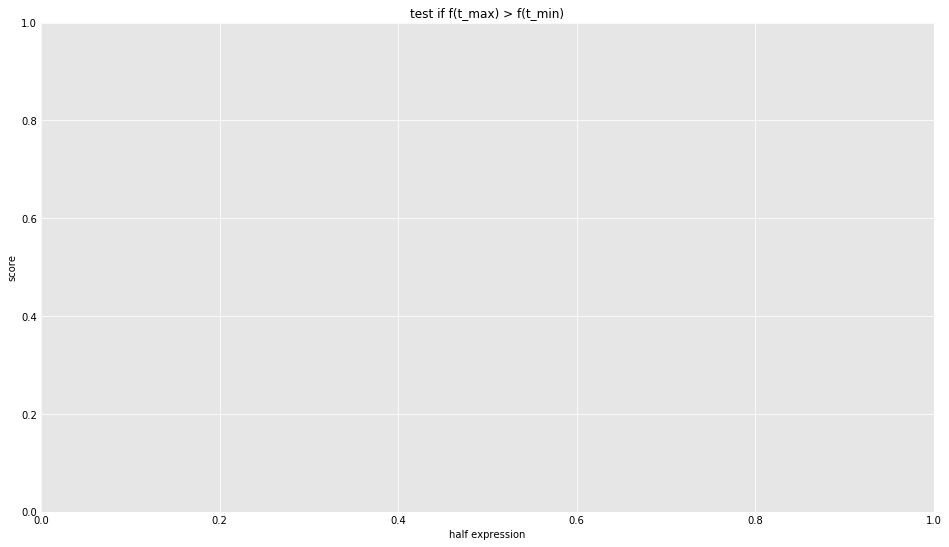

In [131]:

plot('half expression', 'score', 'test if f(t_max) > f(t_min)')
